<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day19_practice3_CLS_%EC%8B%9C%EC%84%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [CLS]의 시선 - ViT는 어디를 보고 분류했나
# Grad-CAM

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, os, urllib.request
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# 셀 1. 데이터
def load_fmnist(root="./data", train=True):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0-1)
  return datasets.FashionMNIST(root=root, train=train, download=True, transform=tf)

train_loader = DataLoader(load_fmnist(train=True), batch_size=128, shuffle=True)
test_data = load_fmnist(train=False)
test_loader = DataLoader(test_data, batch_size=512)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


In [5]:
# 셀 2.
class MultiHeadAttention(nn.Module):
  def __init__(self, dim, n_heads): # dim = 128, n_heads = 8 헤드 수
    super().__init__()

    assert dim % n_heads == 0
    self.n_heads = n_heads
    self.d_heads = dim // n_heads # d_head=8 헤드 하나가 맡는 차원 수

    self.W_q = nn.Linear(dim, dim, bias=False) # 각 헤드마다 Q,K,V를 만들 학습 행렬
    self.W_k = nn.Linear(dim, dim, bias=False)
    self.W_v = nn.Linear(dim, dim, bias=False)
    self.W_o = nn.Linear(dim, dim, bias=False) # 헤드들 결과를 합친 뒤 섞는 출력층

  def forward(self, x, mask=None):
    B, L, D = x.shape # x:(B,17,64) 배치, cls+패치, 벡터차원
    H, dh = self.n_heads, self.d_heads # H=8 헤드수, dh=16 각헤드 차원수

    # 1. 쪼개기 x:(B,17,64)→(B,17,8,8)→(B,8,17,8)
    Q = self.W_q(x).reshape(B, L, H, dh).transpose(1, 2) # (B,8,17,8) 배치, 멀티헤드수, cls+패치, 벡터차원8
    K = self.W_k(x).reshape(B, L, H, dh).transpose(1, 2) # (B,8,17,8)
    V = self.W_v(x).reshape(B, L, H, dh).transpose(1, 2) # (B,8,17,8)

    # 2. 각자 보기 : 셀프어텐션
    scores = Q @ K.transpose(-2, -1) / math.sqrt(dh) # (B,8,17,8) @ (B,8,8,17) → (B,8,17,17) (B, H, QL, KL) 관련도 점수
    if mask is not None:
      scores = scores.masked_fill(mask, -1e9) # masked_fill(조건, 값) 조건이 True인 위치를 값으로 채운다. (-10억 (-무한대))가 softmax를 통과하면 0이 된다.
    attn = F.softmax(scores, dim=-1) # softmax에서 dim=-1 축을 따라 정규화, (축은 그대로 남아있고, 그 축의 값들을 합=1로) (B,8,17,17)
    self.attn_map = attn # 시각화용 저장 (B,8,17,17)
    out = attn @ V # (B,8,17,8)

    # 3. 이어붙이기 : 헤드 8개(각 8차원)를 다시 원래 64차원 한 줄로 이어붙여 입력과 같은 모양 복원
    out = out.transpose(1,2).reshape(B, L, D) # (B,8H,64L,16벡터) → (B,64L,8H,16벡터) → (B,64L,128벡터)

    # 4. 섞기 : 헤드 8개 결과를 어떻게 조합할지도 학습(W_o)
    return self.W_o(out) # (B,17,64)

class TransformerBlock(nn.Module):
  def __init__(self, dim=64, n_heads=8):
    super().__init__()
    self.attn = MultiHeadAttention(dim, n_heads) # 단어끼리 정보 교환
    self.norm1 = nn.LayerNorm(dim)
    self.ffn = nn.Sequential( # FFN
        nn.Linear(dim, dim * 4), nn.ReLU(), nn.Linear(dim * 4, dim)
    )
    self.norm2 = nn.LayerNorm(dim)

  def forward(self, x, mask=None): # x:h(B,64L,128벡터)
    x = self.norm1(x + self.attn(x, mask)) # ＋× 잔차
    x = self.norm2(x + self.ffn(x))
    return x # (B,64L,128벡터) 입력과 똑같은 모양

In [6]:
# 셀 3. ViT
PATCH, DIM, N_PATCH = 7, 64, 16

class ViT(nn.Module):
  def __init__(self, n_blocks=2, n_heads=8):
    super().__init__()
    self.patch_embed = nn.Linear(PATCH * PATCH, DIM) # 49→64 차원 임베딩
    self.cls = nn.Parameter(torch.zeros(1,1,DIM)) # (1,1,64)요약 토큰
    self.pos = nn.Parameter(torch.zeros(1,N_PATCH + 1, DIM)) # (1,17,64) 위치 임베딩
    self.blocks = nn.ModuleList(
        TransformerBlock(DIM, n_heads) for _ in range(n_blocks)
    )
    self.head = nn.Linear(DIM, 10) # 64→10클래스 ([CLS]→분류)

  def to_patches(self, images):
    B = images.shape[0]
    p = images.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH) # (B,1,4,4,7,7)
    return p.reshape(B, N_PATCH, PATCH * PATCH) # (B,16,49) 16패치, 49픽셀

  def forward(self, images): # images:(B,1,28,28)
    x = self.patch_embed(self.to_patches(images)) # (B,1,28,28)→(B,16,49)→(B,16,64)
    x = torch.cat([self.cls.expand(x.size(0), -1, -1), x], 1) # (B,1,64)+(B,16,64)→(B,17,64)
    x = x + self.pos # (B,17,64) 위치 임베딩 더함
    for b in self.blocks:
      x = b(x) # (B,17,64)
    return self.head(x[:, 0]) # (B,64) cls 자리만 → (B,10) CLS가 어텐션으로 16패치를 다 모은 요약 그 벡터 하나로 분류

vit = ViT().to(device)
n_vit = sum(p.numel() for p in vit.parameters())
print(f"ViT 파라미터: {n_vit/1e3:.0f}K")

ViT 파라미터: 104K


In [7]:
# 셀 1. 학습된 ViT 준비
if os.path.exists("vit_fmnist.pt"):
  vit.load_state_dict(torch.load("vit_fmnist.pt", map_location=device))
  print("vit_fmnist.pt 로드(실습 2 결과)")

vit_fmnist.pt 로드(실습 2 결과)


In [8]:
test_data = load_fmnist(train=False)
classes = test_data.classes

In [9]:
# 셀 2. [CLS]의 시선 - 어텐션에서 그냥 꺼내면 된다
def cls_attention(model, image):
  model.eval()
  with torch.no_grad():
    pred = model(image.unsqueeze(0).to(device)).argmax(1).item() # unsqueeze:(1,1,28,28)→(1,10)→int
  amap = model.blocks[-1].attn.attn_map # (1,8,17,17) 마지막 블록 어텐션 맵
  gaze = amap[0,:,0,1:].mean(0) # (8,16) → (16,) CLS 자신 제외
  gaze = gaze.reshape(4,4)
  gaze = F.interpolate(gaze[None, None], size=(28,28), mode="bilinear")[0,0] # (4,4)→(28,28)
  gaze = (gaze - gaze.min()) / (gaze.max() - gaze.min() + 1e-8) # 0~1 정규화(색 일정)
  return gaze.cpu(), pred # gaze:(28,28). pred:int

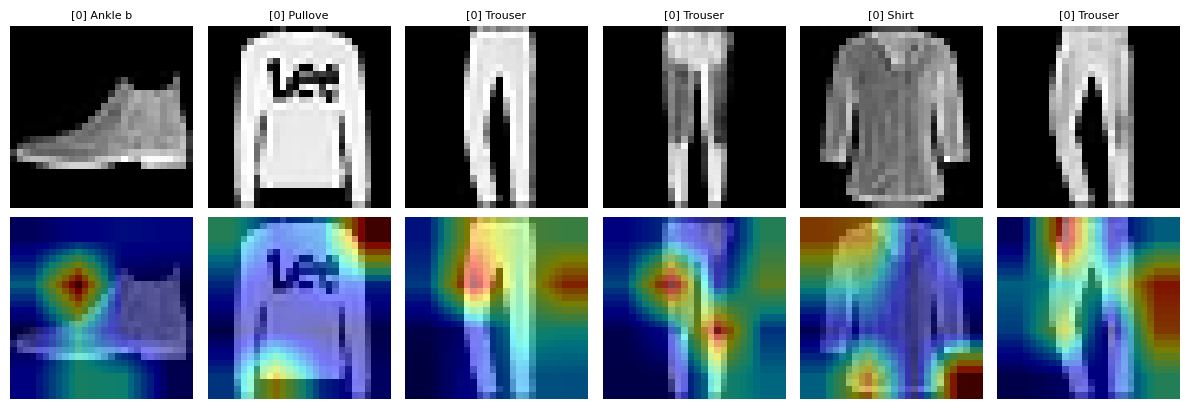

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(12,4.2))
for i in range(6):
  img, label = test_data[i] #img:(1,28,28)
  gaze, pred = cls_attention(vit, img) # gaze:(28,28), pred:int
  ok = "0" if pred == label else "X"
  axes[0, i].imshow(img[0], cmap="gray") # 윗줄: 원본
  axes[0, i].set_title(f"[{ok}] {classes[pred][:7]}", fontsize=8)
  axes[1, i].imshow(img[0], cmap="gray") # 아랫줄: 원본 깔고
  axes[1, i].imshow(gaze, cmap="jet", alpha=0.5) # grad-cma
  for r in range(2): axes[r, i].axis("off")
plt.tight_layout(); plt.savefig("plot1_cls_gaze.png")
plt.show()
# [CLS]가 주목한 패치가 빨갛게, 패치를 잘게 자를수록 시선이 촘촘해진다